In [9]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# IMPORTANDO DADOS

In [10]:
df_target = pd.read_csv('Target/output/data.csv')
df_target

,time,target_yaw,target_wz,target_wy,target_tmp,target_e,target_roll,target_wx,target_ay,target_pitch,target_ax,target_az,static
0,0.0,5.416,-29.72311,0.69735,50.7,3.168,-0.012,5.73980,10.291363,5.690,0.492372,-0.087240,False
1,0.1,5.365,-27.21794,0.31555,50.7,6.120,0.479,4.63504,10.162828,8.535,0.434974,-0.171234,False
2,0.2,5.307,-23.70273,0.66688,50.8,8.748,0.915,3.65632,10.044334,11.083,0.352696,-0.354030,False
3,0.3,5.247,-17.93960,-0.15860,50.7,10.800,1.271,3.30784,9.532240,13.199,0.231192,0.168684,False
4,0.4,5.199,-12.63890,0.35007,50.9,12.276,1.524,1.79823,9.415345,14.754,0.283520,-0.115483,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2743,274.2,7.649,-0.29984,0.06138,54.5,0.396,-0.579,0.25000,9.770395,3.359,0.599961,-0.092712,True
2744,274.3,7.649,-0.17035,-0.34457,54.2,0.396,-0.577,0.37820,9.766962,3.359,0.571483,-0.130066,True
2745,274.4,7.651,-0.30838,0.31484,54.5,0.396,-0.579,-0.06058,9.765207,3.359,0.585251,-0.111364,True
2746,274.5,7.651,0.32828,-0.00989,54.5,0.396,-0.578,0.17020,9.774916,3.359,0.570021,-0.102156,True


In [11]:
df_ref = pd.read_csv('Reference/output/data.csv')
df_ref

,time,ref_yaw,ref_wz,ref_wy,ref_q1,ref_q3,ref_roll,ref_wx,ref_ay,ref_q2,ref_sample_time,ref_q0,ref_la_pos_mon_d,ref_pitch,ref_ax,ref_az,static
0,0.0,37.247986,29.759428,-0.075630,-0.6806,0.2854,-88.808458,0.049085,10.340,-0.1632,505000000.0,0.6548,-3.240,10.061139,0.128400,-0.1994,False
1,0.1,37.247986,27.427490,0.195722,-0.6845,0.3011,-88.808458,0.037546,10.310,-0.1461,605000000.0,0.6476,-3.257,12.880091,0.062020,-0.1900,False
2,0.2,37.265175,23.531377,0.226777,-0.6877,0.3148,-88.808458,-0.130634,10.180,-0.1312,705000000.0,0.6410,-3.276,15.349539,-0.006405,-0.1802,False
3,0.3,37.282364,18.409134,0.211479,-0.6900,0.3257,-88.808458,-0.155845,10.030,-0.1191,805000000.0,0.6354,-3.295,17.343432,-0.063050,-0.1864,False
4,0.4,37.305282,12.186812,0.004055,-0.6915,0.3334,-88.865754,-0.209301,9.865,-0.1107,905000000.0,0.6312,-3.310,18.735720,-0.113800,-0.1910,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2743,274.2,73.739668,0.004392,-0.136937,-0.5792,0.4532,-88.923050,-0.014948,9.784,-0.3938,705000000.0,0.5514,1.307,5.201311,0.137400,-0.1871,True
2744,274.3,73.739668,0.007546,-0.125650,-0.5791,0.4532,-88.923050,-0.005741,9.784,-0.3939,805000000.0,0.5514,1.303,5.201311,0.137600,-0.1871,True
2745,274.4,73.739668,0.001083,-0.139401,-0.5791,0.4533,-88.923050,-0.017469,9.783,-0.3939,905000000.0,0.5513,1.300,5.200738,0.137200,-0.1869,True
2746,274.5,73.739668,0.000704,-0.119061,-0.5791,0.4534,-88.923050,0.001478,9.784,-0.3940,5000000.0,0.5513,1.296,5.200738,0.137600,-0.1874,True


In [12]:
df = pd.merge_asof(df_target, df_ref, on='time', by='static', direction='nearest')
df

,time,target_yaw,target_wz,target_wy,target_tmp,target_e,target_roll,target_wx,target_ay,target_pitch,target_ax,target_az,static,ref_yaw,ref_wz,ref_wy,ref_q1,ref_q3,ref_roll,ref_wx,ref_ay,ref_q2,ref_sample_time,ref_q0,ref_la_pos_mon_d,ref_pitch,ref_ax,ref_az
0,0.0,5.416,-29.72311,0.69735,50.7,3.168,-0.012,5.73980,10.291363,5.690,0.492372,-0.087240,False,37.247986,29.759428,-0.075630,-0.6806,0.2854,-88.808458,0.049085,10.340,-0.1632,505000000.0,0.6548,-3.240,10.061139,0.128400,-0.1994
1,0.1,5.365,-27.21794,0.31555,50.7,6.120,0.479,4.63504,10.162828,8.535,0.434974,-0.171234,False,37.247986,27.427490,0.195722,-0.6845,0.3011,-88.808458,0.037546,10.310,-0.1461,605000000.0,0.6476,-3.257,12.880091,0.062020,-0.1900
2,0.2,5.307,-23.70273,0.66688,50.8,8.748,0.915,3.65632,10.044334,11.083,0.352696,-0.354030,False,37.265175,23.531377,0.226777,-0.6877,0.3148,-88.808458,-0.130634,10.180,-0.1312,705000000.0,0.6410,-3.276,15.349539,-0.006405,-0.1802
3,0.3,5.247,-17.93960,-0.15860,50.7,10.800,1.271,3.30784,9.532240,13.199,0.231192,0.168684,False,37.282364,18.409134,0.211479,-0.6900,0.3257,-88.808458,-0.155845,10.030,-0.1191,805000000.0,0.6354,-3.295,17.343432,-0.063050,-0.1864
4,0.4,5.199,-12.63890,0.35007,50.9,12.276,1.524,1.79823,9.415345,14.754,0.283520,-0.115483,False,37.305282,12.186812,0.004055,-0.6915,0.3334,-88.865754,-0.209301,9.865,-0.1107,905000000.0,0.6312,-3.310,18.735720,-0.113800,-0.1910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2743,274.2,7.649,-0.29984,0.06138,54.5,0.396,-0.579,0.25000,9.770395,3.359,0.599961,-0.092712,True,73.739668,0.004392,-0.136937,-0.5792,0.4532,-88.923050,-0.014948,9.784,-0.3938,705000000.0,0.5514,1.307,5.201311,0.137400,-0.1871
2744,274.3,7.649,-0.17035,-0.34457,54.2,0.396,-0.577,0.37820,9.766962,3.359,0.571483,-0.130066,True,73.739668,0.007546,-0.125650,-0.5791,0.4532,-88.923050,-0.005741,9.784,-0.3939,805000000.0,0.5514,1.303,5.201311,0.137600,-0.1871
2745,274.4,7.651,-0.30838,0.31484,54.5,0.396,-0.579,-0.06058,9.765207,3.359,0.585251,-0.111364,True,73.739668,0.001083,-0.139401,-0.5791,0.4533,-88.923050,-0.017469,9.783,-0.3939,905000000.0,0.5513,1.300,5.200738,0.137200,-0.1869
2746,274.5,7.651,0.32828,-0.00989,54.5,0.396,-0.578,0.17020,9.774916,3.359,0.570021,-0.102156,True,73.739668,0.000704,-0.119061,-0.5791,0.4534,-88.923050,0.001478,9.784,-0.3940,5000000.0,0.5513,1.296,5.200738,0.137600,-0.1874


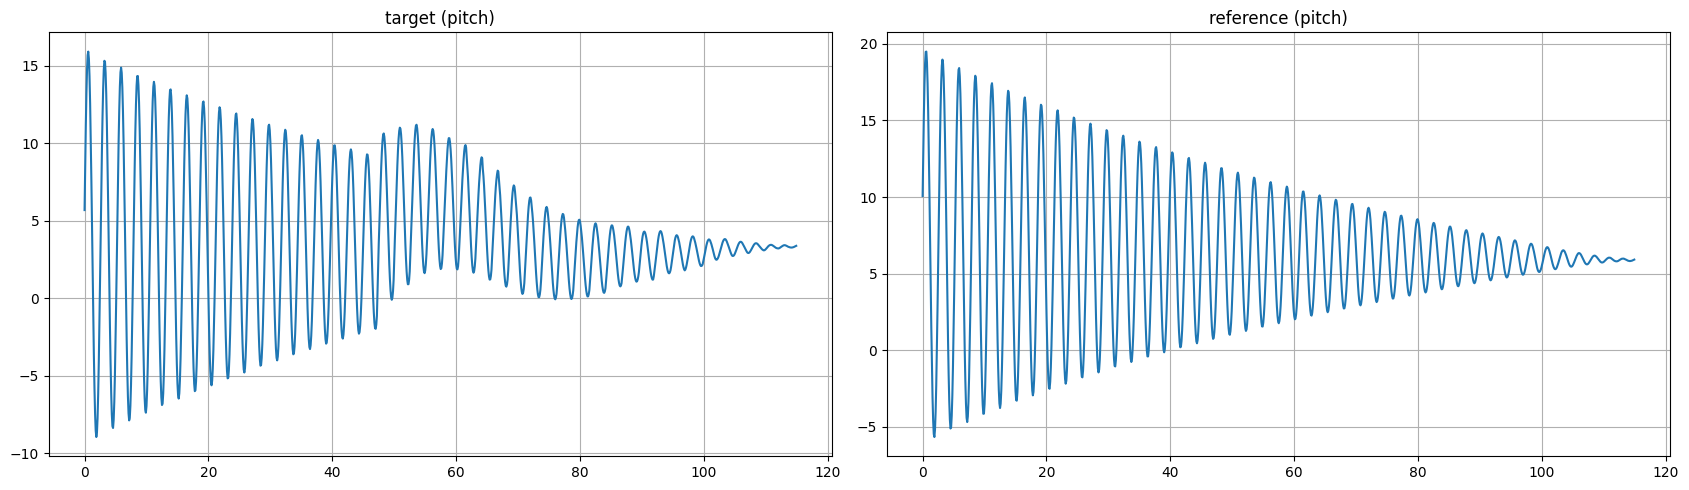

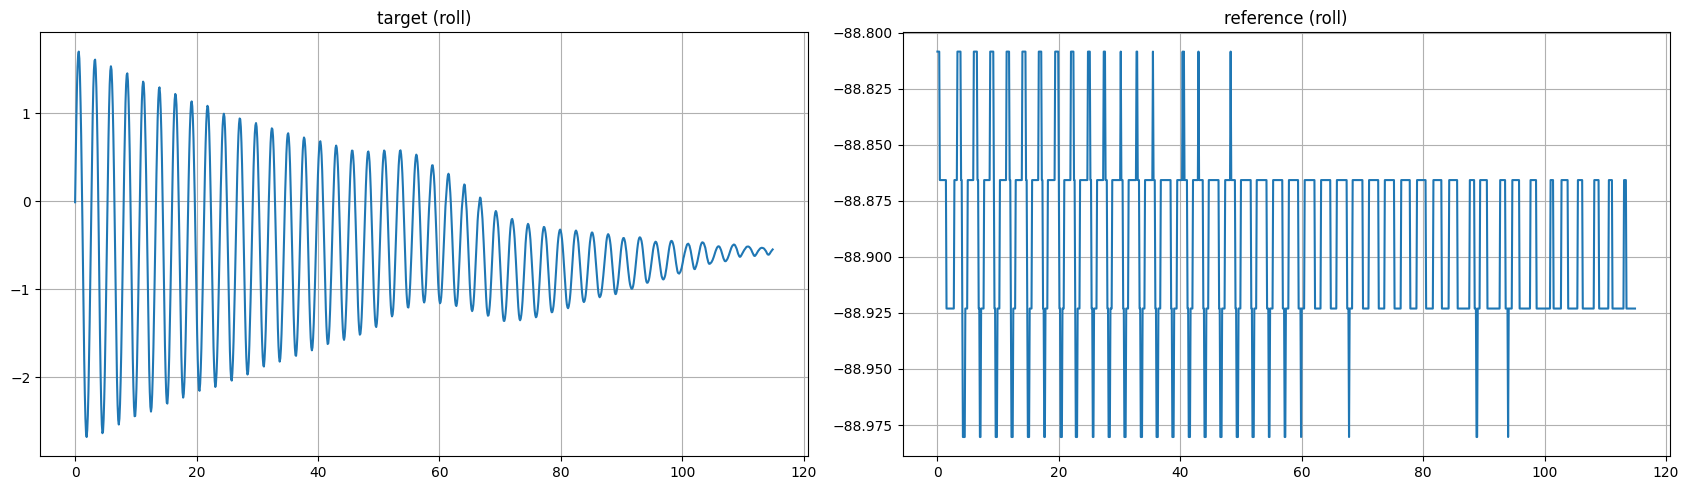

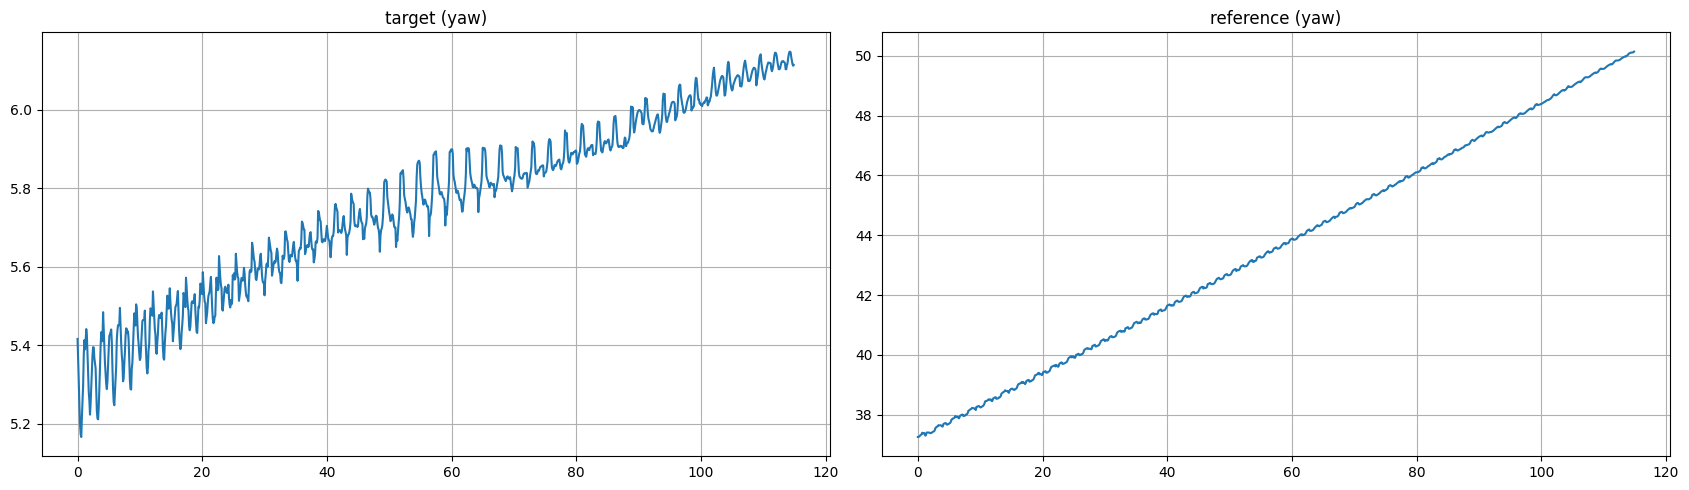

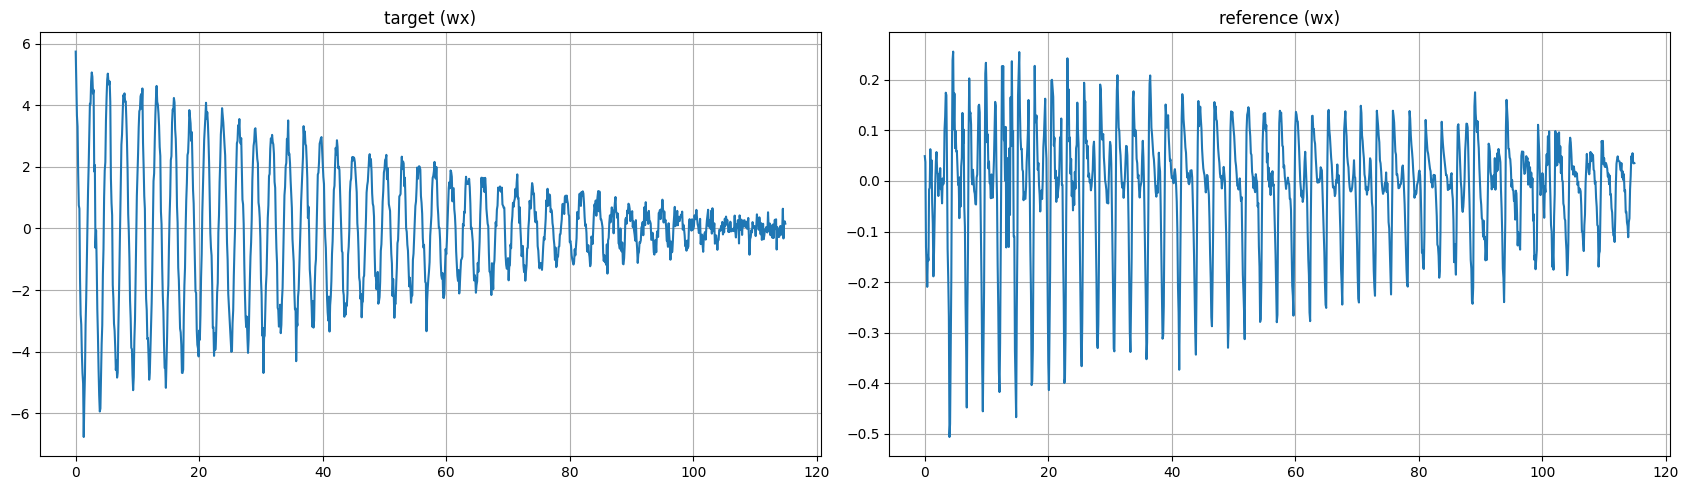

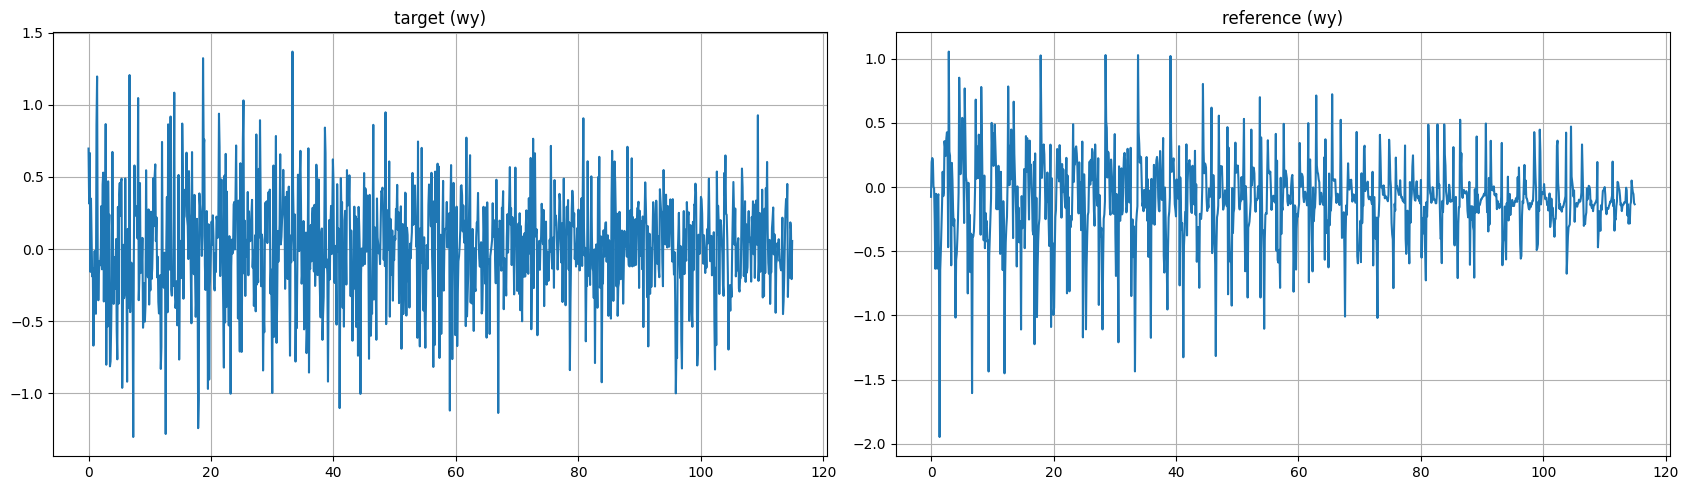

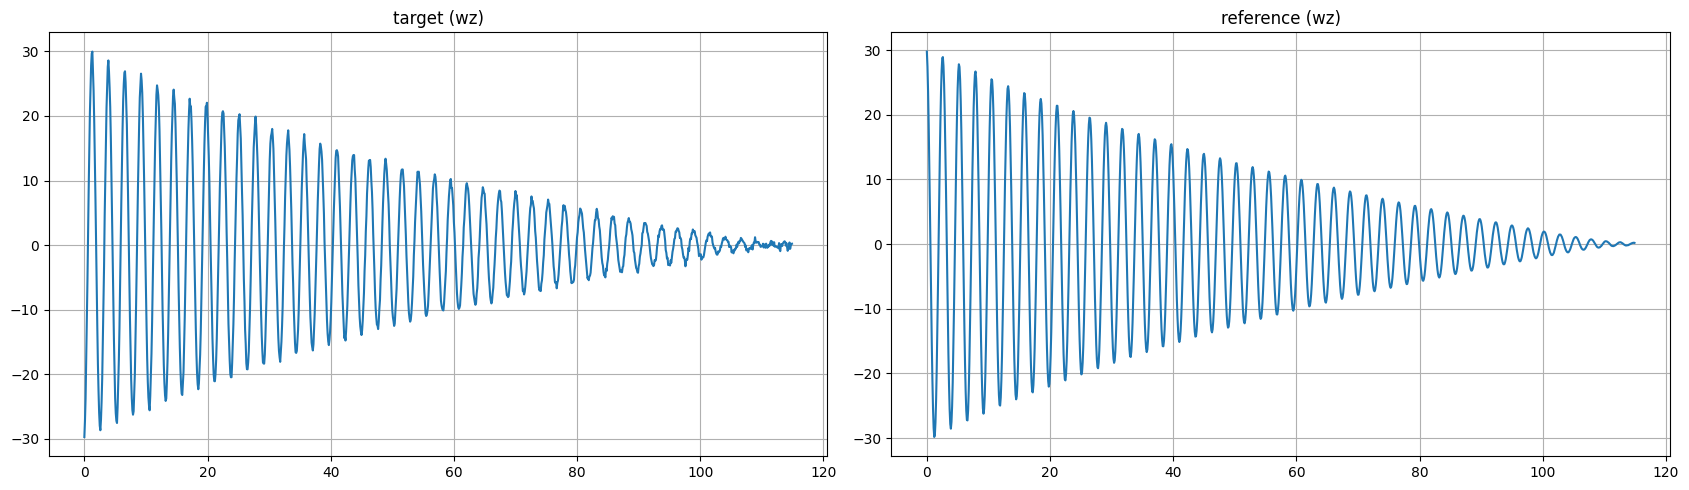

In [13]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df.loc[~df.static][f'target_{var}'], 
        f'reference ({var})': df.loc[~df.static][f'ref_{var}']
    }, time=df.loc[~df.static].time, figsize=(17, 5))

# REMOVENDO A BARRIGUINHA

In [14]:
def clearBarriguinha(df, undesired=(45, 80)):
    # Desempacota os limites do intervalo
    start_time, end_time = undesired
    
    # 1. Pega os dados ANTES da barriguinha
    df_before = df[df['time'] < start_time].copy()
    
    # 2. Pega os dados DEPOIS da barriguinha
    df_after = df[df['time'] > end_time].copy()
    
    # 3. Calcula o tamanho do gap (duração da barriguinha)
    gap_duration = end_time - start_time
    
    # 4. Desloca o tempo dos dados 'depois' para trás, fechando o buraco
    df_after['time'] = df_after['time'] - gap_duration
    
    # 5. Junta os dois pedaços e reseta o índice
    df_cleaned = pd.concat([df_before, df_after]).reset_index(drop=True)
    
    return df_cleaned



test = json.loads(open('../info.json', 'r', encoding='utf-8').read())['target']['test']
axis = json.loads(open('../info.json', 'r', encoding='utf-8').read())['target']['axis']
interval = json.loads(open(f'files/test{test}/rolling_{axis}/info.json', 'r', encoding='utf-8').read()).get('belly')
print(interval)

df = clearBarriguinha(df, interval)
df.head()

[45, 80]


,time,target_yaw,target_wz,target_wy,target_tmp,target_e,target_roll,target_wx,target_ay,target_pitch,target_ax,target_az,static,ref_yaw,ref_wz,ref_wy,ref_q1,ref_q3,ref_roll,ref_wx,ref_ay,ref_q2,ref_sample_time,ref_q0,ref_la_pos_mon_d,ref_pitch,ref_ax,ref_az
0,0.0,5.416,-29.72311,0.69735,50.7,3.168,-0.012,5.73980,10.291363,5.690,0.492372,-0.087240,False,37.247986,29.759428,-0.075630,-0.6806,0.2854,-88.808458,0.049085,10.340,-0.1632,505000000.0,0.6548,-3.240,10.061139,0.128400,-0.1994
1,0.1,5.365,-27.21794,0.31555,50.7,6.120,0.479,4.63504,10.162828,8.535,0.434974,-0.171234,False,37.247986,27.427490,0.195722,-0.6845,0.3011,-88.808458,0.037546,10.310,-0.1461,605000000.0,0.6476,-3.257,12.880091,0.062020,-0.1900
2,0.2,5.307,-23.70273,0.66688,50.8,8.748,0.915,3.65632,10.044334,11.083,0.352696,-0.354030,False,37.265175,23.531377,0.226777,-0.6877,0.3148,-88.808458,-0.130634,10.180,-0.1312,705000000.0,0.6410,-3.276,15.349539,-0.006405,-0.1802
3,0.3,5.247,-17.93960,-0.15860,50.7,10.800,1.271,3.30784,9.532240,13.199,0.231192,0.168684,False,37.282364,18.409134,0.211479,-0.6900,0.3257,-88.808458,-0.155845,10.030,-0.1191,805000000.0,0.6354,-3.295,17.343432,-0.063050,-0.1864
4,0.4,5.199,-12.63890,0.35007,50.9,12.276,1.524,1.79823,9.415345,14.754,0.283520,-0.115483,False,37.305282,12.186812,0.004055,-0.6915,0.3334,-88.865754,-0.209301,9.865,-0.1107,905000000.0,0.6312,-3.310,18.735720,-0.113800,-0.1910


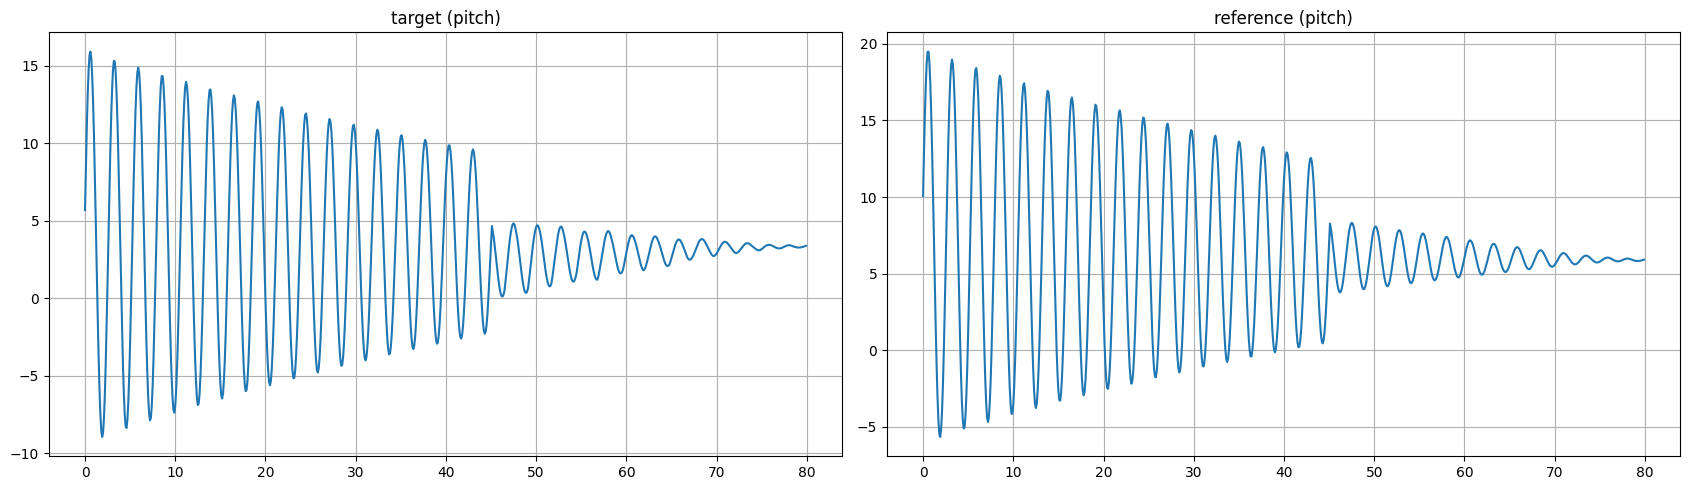

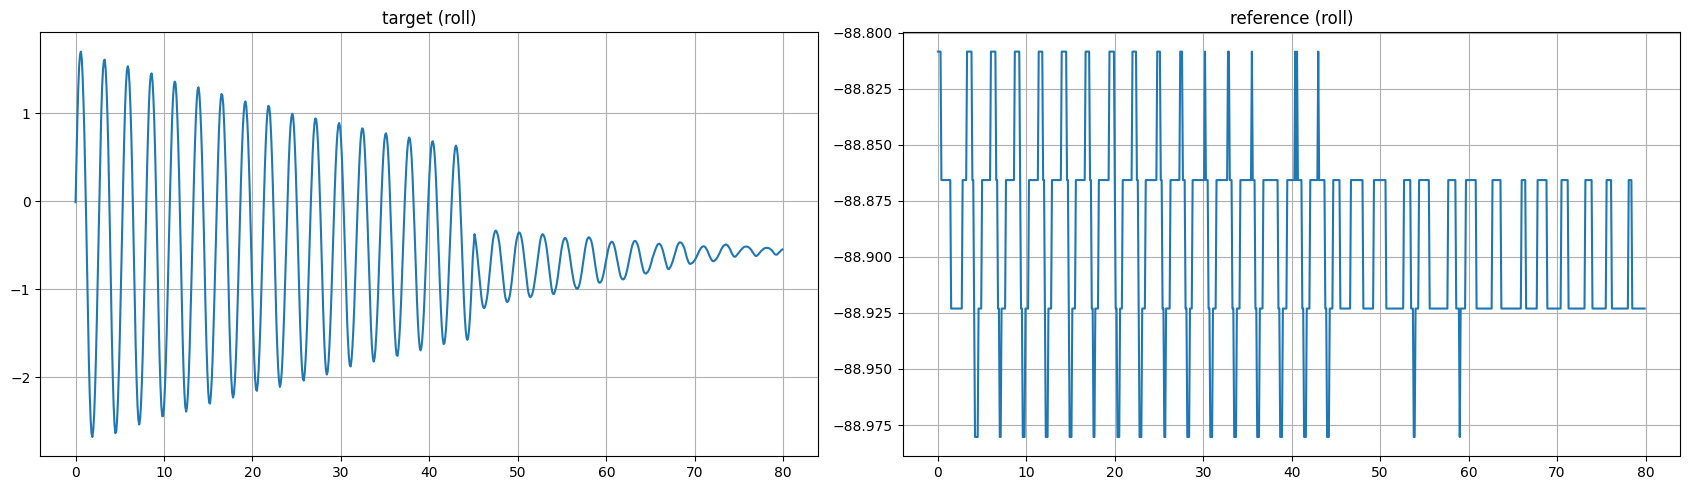

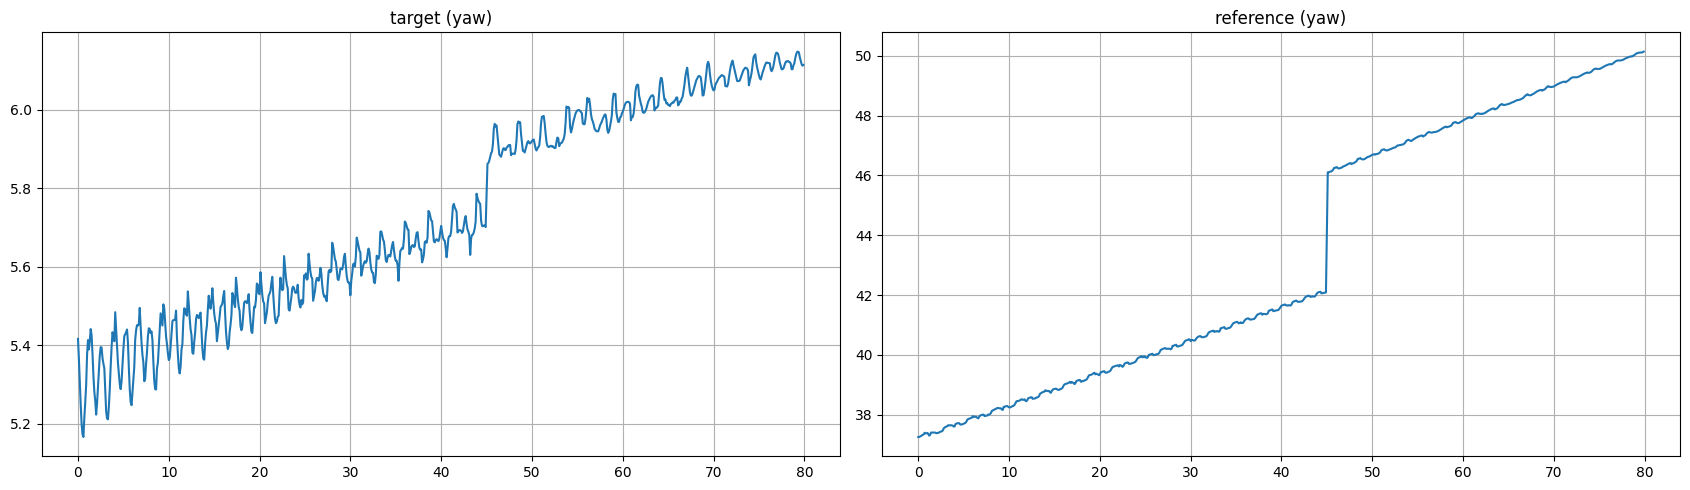

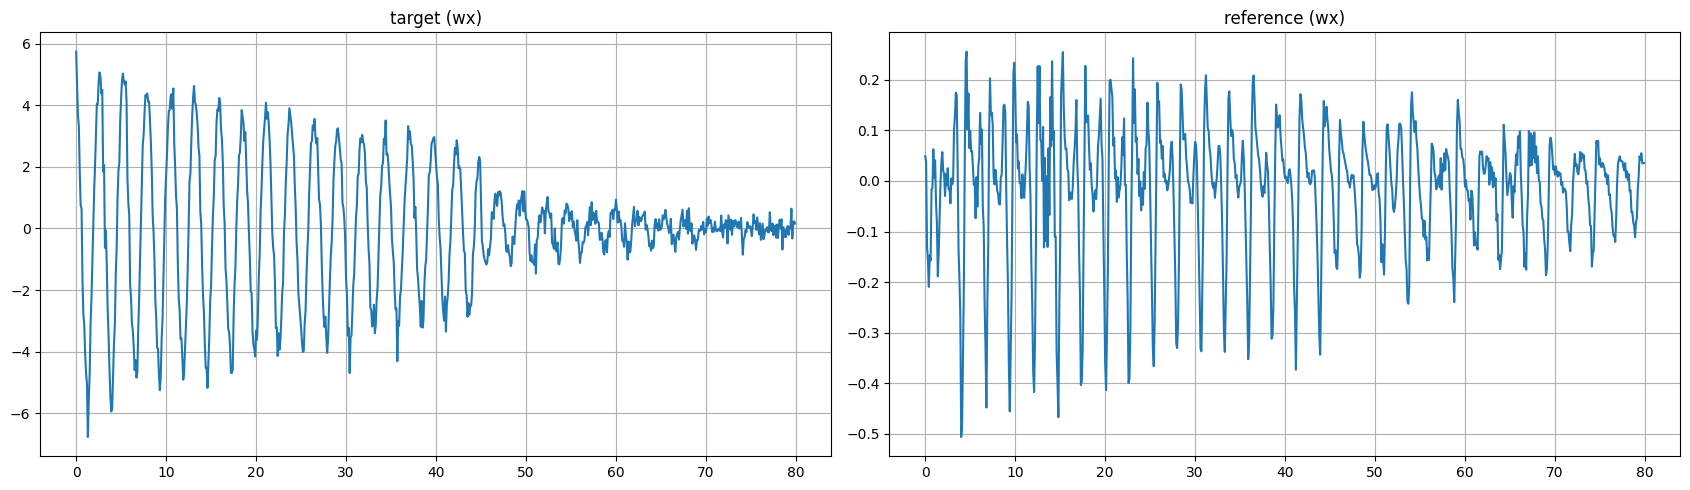

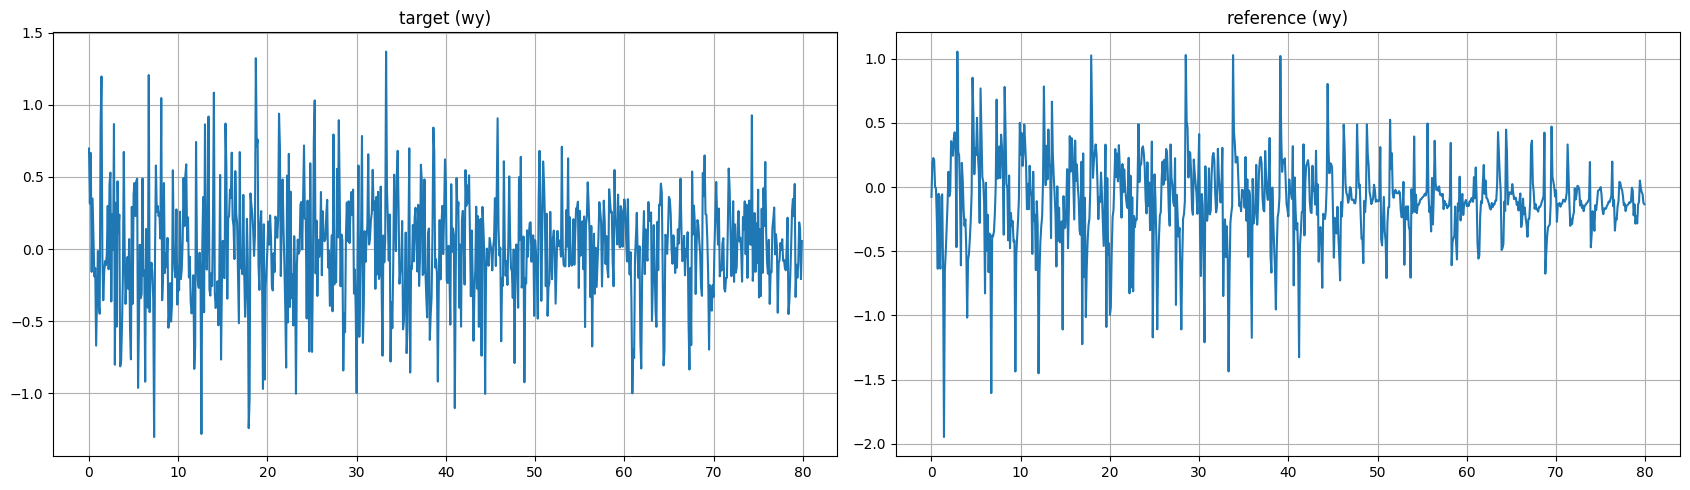

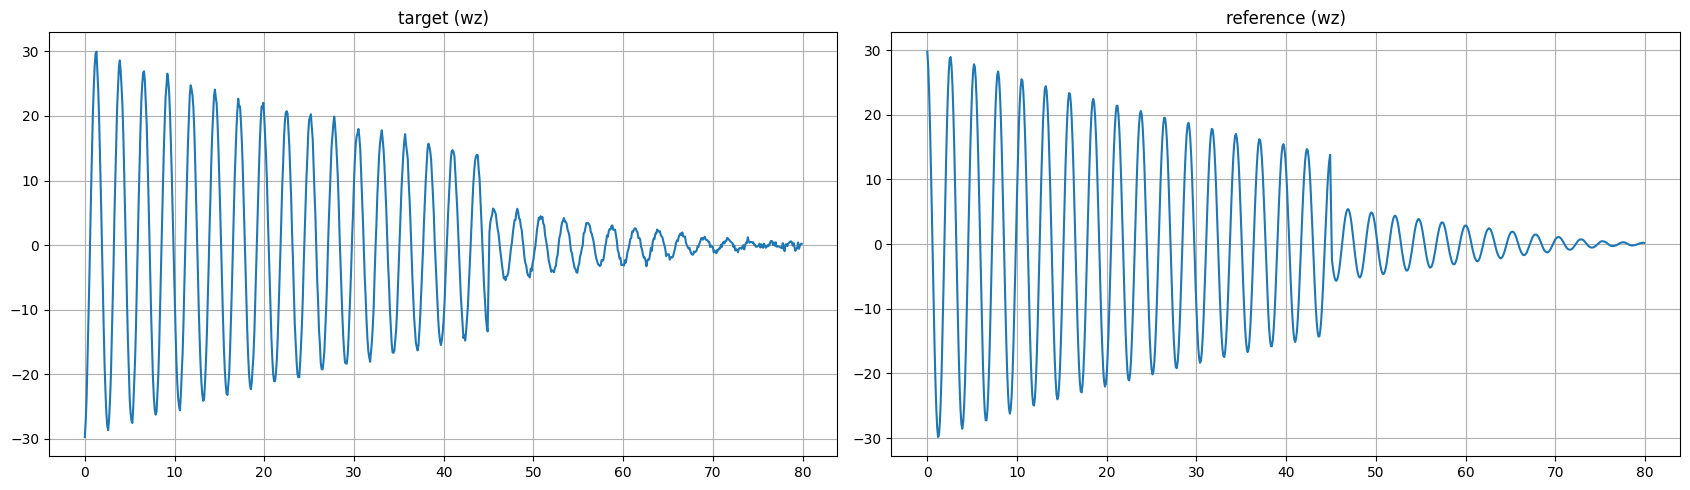

In [15]:
for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df.loc[~df.static][f'target_{var}'], 
        f'reference ({var})': df.loc[~df.static][f'ref_{var}']
    }, time=df.loc[~df.static].time, figsize=(17, 5))

# SALVANDO DADOS

In [16]:
os.makedirs('files', exist_ok=True)
df.to_csv('files/output.csv', index=None)